# Bearing Health-State Classification and RUL Prediction

This notebook trains and compares Random Forest and Gradient Boosting models to predict the Remaining Useful Life (RUL) of bearings using extracted vibration features. The best model is then used for health-state classification and test-set prediction.

Import Libraries
- Required Python libraries for data handling, model training, evaluation, saving the model, and visualization. 

In [49]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Load Training Feature Data
- The file `train_features.csv` contains the extracted vibration features and the target RUL values.

In [50]:
DATA_PATH = Path("train_features.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape:
(7534, 16)

Columns:
['rms_x', 'peak_x', 'kurtosis_x', 'skew_x', 'std_x', 'crest_x', 'rms_y', 'peak_y', 'kurtosis_y', 'skew_y', 'std_y', 'crest_y', 'time_step', 'total_steps', 'RUL', 'bearing']


,rms_x,peak_x,kurtosis_x,skew_x,std_x,crest_x,rms_y,peak_y,kurtosis_y,skew_y,std_y,crest_y,time_step,total_steps,RUL,bearing
0,0.561746,2.010,-0.131465,-0.004711,0.561735,3.578132,0.435801,1.591,-0.035080,0.002713,0.435797,3.650745,0,2803,2802,Bearing1_1
1,0.535112,1.915,-0.084646,-0.025791,0.535083,3.578687,0.420968,1.666,0.150620,0.077380,0.420967,3.957542,1,2803,2801,Bearing1_1
2,0.531158,1.901,0.033388,-0.005016,0.531142,3.578971,0.425605,1.584,-0.061552,-0.024393,0.425600,3.721758,2,2803,2800,Bearing1_1
3,0.554833,1.910,0.043419,-0.080165,0.554830,3.442476,0.445524,1.600,-0.113319,-0.008190,0.445524,3.591275,3,2803,2799,Bearing1_1
4,0.566652,1.767,-0.185477,-0.034187,0.566646,3.118317,0.423847,1.373,-0.034816,0.081213,0.423731,3.239377,4,2803,2798,Bearing1_1


Inspect Dataset Columns
- This step checks all available columns to identify feature columns, target column, and bearing identifier.

In [51]:
for i, col in enumerate(df.columns):
    print(i, ":", col)

0 : rms_x
1 : peak_x
2 : kurtosis_x
3 : skew_x
4 : std_x
5 : crest_x
6 : rms_y
7 : peak_y
8 : kurtosis_y
9 : skew_y
10 : std_y
11 : crest_y
12 : time_step
13 : total_steps
14 : RUL
15 : bearing


Prepare Features and Target
- The input features are vibration statistics from x and y accelerometer signals.  
- The target variable is `RUL`, and `bearing` is used for grouped splitting.

In [52]:
# Create normalized life progression feature
df["life_fraction"] = df["time_step"] / df["total_steps"]

feature_cols = [
    'rms_x',
    'peak_x',
    'kurtosis_x',
    'skew_x',
    'std_x',
    'crest_x',
    'rms_y',
    'peak_y',
    'kurtosis_y',
    'skew_y',
    'std_y',
    'crest_y',
    'time_step',
    'life_fraction'
]

X = df[feature_cols]

y = df['RUL']

groups = df['bearing']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7534, 14)
Target shape: (7534,)


Train-Test Split by Bearing
- The dataset is split by bearing using `GroupShuffleSplit` to avoid data leakage.  
- This ensures samples from the same bearing are not present in both training and test sets.

In [53]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

Train samples: 3860
Test samples: 3674


In [54]:
train_bearings = set(groups.iloc[train_idx])
validation_bearings = set(groups.iloc[test_idx])

print("Training bearings:", train_bearings)
print("Validation bearings:", validation_bearings)

overlap = train_bearings.intersection(validation_bearings)

print("Overlap:", overlap)

if len(overlap) == 0:
    print("No data leakage: training and validation bearings are separate.")
else:
    print("Warning: data leakage detected.")

Training bearings: {'Bearing2_1', 'Bearing3_1', 'Bearing3_2', 'Bearing2_2'}
Validation bearings: {'Bearing1_1', 'Bearing1_2'}
Overlap: set()
No data leakage: training and validation bearings are separate.


In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import numpy as np

print("\n" + "="*80)
print("AUTOMATED HYPERPARAMETER TUNING")
print("="*80)

# Try 1: Random Forest with GridSearchCV
print("\n1. Tuning Random Forest...")
rf_params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [8, 12, 15],
    'min_samples_leaf': [3, 5, 8],
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_params, cv=5, scoring='r2', n_jobs=-1
)
rf_grid.fit(X_train, y_train)

rf_pred = rf_grid.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
print(f"   Best R²: {rf_r2:.4f}")
print(f"   Parameters: {rf_grid.best_params_}")

# Try 2: Gradient Boosting
print("\n2. Tuning Gradient Boosting...")
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params, cv=5, scoring='r2'
)
gb_grid.fit(X_train, y_train)

gb_pred = gb_grid.predict(X_test)
gb_r2 = r2_score(y_test, gb_pred)
print(f"   Best R²: {gb_r2:.4f}")
print(f"   Parameters: {gb_grid.best_params_}")

# Compare and choose best
print("\n" + "="*80)
print("RESULTS COMPARISON")
print("="*80)
print(f"Random Forest:     R² = {rf_r2:.4f}")
print(f"Gradient Boosting: R² = {gb_r2:.4f}")

if rf_r2 > gb_r2:
    print(f"\n Random Forest")
    model = rf_grid.best_estimator_
else:
    print(f"\n Gradient Boosting")
    model = gb_grid.best_estimator_

print(f"Expected R² after final training on all data: ~{max(rf_r2, gb_r2):.4f}")


AUTOMATED HYPERPARAMETER TUNING

1. Tuning Random Forest...
   Best R²: -0.1045
   Parameters: {'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 150}

2. Tuning Gradient Boosting...
   Best R²: 0.1989
   Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

RESULTS COMPARISON
Random Forest:     R² = -0.1045
Gradient Boosting: R² = 0.1989

 Gradient Boosting
Expected R² after final training on all data: ~0.1989


Generate RUL Predictions
- The trained model predicts RUL values for the held-out test bearings.

In [56]:
y_pred = model.predict(X_test)

print("Predictions complete!")

print(y_pred[:10])

Predictions complete!
[542.3655452  515.75502414 565.42072393 705.84605801 705.28851774
 822.65218924 841.67417916 846.40603627 835.7712118  771.64877668]


Evaluate Model Performance
- The model is evaluated using RMSE, MAE, and R² score.

In [57]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 739.8636681308541
MAE: 576.5055383213022
R2 Score: 0.1988686611961944


Calculate PHM Score
- The PHM score is an asymmetric metric that penalizes late predictions more strongly than early predictions.

In [58]:
def phm_score(y_true, y_pred):

    score = 0

    for true, pred in zip(y_true, y_pred):

        d = pred - true

        if d < 0:
            score += np.exp(-d / 13) - 1

        else:
            score += np.exp(d / 10) - 1

    return score


score = phm_score(y_test.values, y_pred)

print("PHM Score:", score)

PHM Score: 2.5594956580541294e+76


In [59]:
prediction_mean = model.predict(X_test)

residuals = y_test.values - prediction_mean

prediction_std = np.full(
    shape=len(prediction_mean),
    fill_value=np.std(residuals)
)

print("Uncertainty estimation complete!")
print("Estimated uncertainty:", prediction_std[0])

Uncertainty estimation complete!
Estimated uncertainty: 484.97706042776844


Create Results Table

The final results table contains:

- Actual Remaining Useful Life (RUL)
- Predicted RUL
- Prediction uncertainty
- 95% confidence bounds
- Actual health-state class
- Predicted health-state class

This table summarizes the performance of the predictive maintenance model
and converts continuous RUL predictions into practical maintenance categories.

In [60]:
results = df.iloc[test_idx][["bearing", "time_step", "total_steps"]].copy()

results["Actual_RUL"] = y_test.values
results["Predicted_RUL"] = prediction_mean
results["Uncertainty"] = prediction_std
results["Lower_RUL"] = prediction_mean - 1.96 * prediction_std
results["Upper_RUL"] = prediction_mean + 1.96 * prediction_std


def rul_to_health_state(rul):
    if rul > 200:
        return "Non-critical"
    elif rul > 80:
        return "Wear detectable"
    else:
        return "Imminent failure"


results["Actual_Health_State"] = results["Actual_RUL"].apply(rul_to_health_state)
results["Predicted_Health_State"] = results["Predicted_RUL"].apply(rul_to_health_state)

results.head()

,bearing,time_step,total_steps,Actual_RUL,Predicted_RUL,Uncertainty,Lower_RUL,Upper_RUL,Actual_Health_State,Predicted_Health_State
0,Bearing1_1,0,2803,2802,542.365545,484.97706,-408.189493,1492.920584,Non-critical,Non-critical
1,Bearing1_1,1,2803,2801,515.755024,484.97706,-434.800014,1466.310063,Non-critical,Non-critical
2,Bearing1_1,2,2803,2800,565.420724,484.97706,-385.134315,1515.975762,Non-critical,Non-critical
3,Bearing1_1,3,2803,2799,705.846058,484.97706,-244.708980,1656.401096,Non-critical,Non-critical
4,Bearing1_1,4,2803,2798,705.288518,484.97706,-245.266521,1655.843556,Non-critical,Non-critical


Save Prediction Results

The final prediction results are saved as:

- `rul_predictions_with_health_states.csv`

The saved file contains:

- Actual RUL
- Predicted RUL
- Prediction uncertainty
- Confidence intervals
- Actual health-state labels
- Predicted health-state labels

This file can be used for further visualization, reporting, and maintenance analysis.

In [61]:
results.to_csv("rul_predictions_with_health_states.csv", index=False)

print("Saved rul_predictions_with_health_states.csv")

Saved rul_predictions_with_health_states.csv


Health-State Classification Evaluation

This step evaluates how well the predicted Remaining Useful Life (RUL) values map to bearing health conditions.

The predicted and actual RUL values are converted into three health-state classes:

- Non-critical → Bearing operating normally
- Wear detectable → Early degradation detected
- Imminent failure → Bearing close to failure

The following evaluation metrics are computed:

- Classification accuracy
- Precision, recall, and F1-score
- Confusion matrix for class-wise performance analysis

This provides an interpretable maintenance-oriented assessment of the predictive maintenance system.

In [62]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

health_accuracy = accuracy_score(
    results["Actual_Health_State"],
    results["Predicted_Health_State"]
)

print("Health-State Classification Accuracy:", health_accuracy)

print("\nClassification Report:")
print(classification_report(
    results["Actual_Health_State"],
    results["Predicted_Health_State"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    results["Actual_Health_State"],
    results["Predicted_Health_State"]
))

Health-State Classification Accuracy: 0.8818726183995645

Classification Report:
                  precision    recall  f1-score   support

Imminent failure       0.60      0.99      0.75       162
    Non-critical       1.00      0.90      0.95      3272
 Wear detectable       0.29      0.55      0.38       240

        accuracy                           0.88      3674
       macro avg       0.63      0.82      0.69      3674
    weighted avg       0.94      0.88      0.90      3674


Confusion Matrix:
[[ 161    0    1]
 [   1 2946  325]
 [ 107    0  133]]


Visualization: Predicted Health-State Distribution

- This visualization shows the number of predicted samples in each bearing health-state category.
- The categories help interpret bearing condition for predictive maintenance:
  - Non-critical
  - Wear detectable
  - Imminent failure
- This plot provides an overview of the maintenance condition distribution across the dataset.

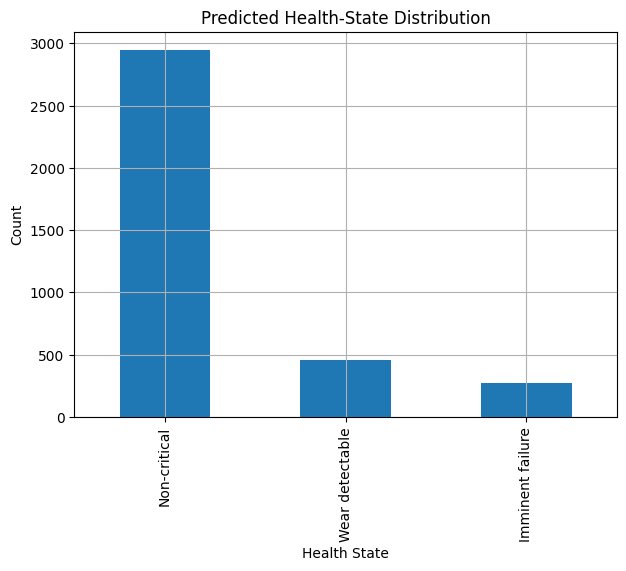

In [63]:
import matplotlib.pyplot as plt

results["Predicted_Health_State"].value_counts().plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Predicted Health-State Distribution")
plt.xlabel("Health State")
plt.ylabel("Count")
plt.grid(True)

plt.show()

Train Final Model on All Training Bearings

After validation, the final Gradient Boost model is trained again using all available training data.  
This final model is then saved and used for prediction on the real unseen `Test_set` bearings.

In [64]:
final_model = GradientBoostingRegressor(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=200,
    random_state=42
)

print("Training final Gradient Boosting model on all training data...")

final_model.fit(X, y)

model = final_model

print("Final Gradient Boosting model trained on all training bearings.")

Training final Gradient Boosting model on all training data...
Final Gradient Boosting model trained on all training bearings.


Save Trained Model
- The trained Random Forest model is saved as a `.pkl` file for future reuse.

In [65]:
import joblib

joblib.dump(model, "gradient_boosting_rul_model.pkl")

print("Gradient Boosting model saved!")

Gradient Boosting model saved!


Visualization: Actual vs Predicted RUL
- This plot compares the true RUL values with the model predictions.

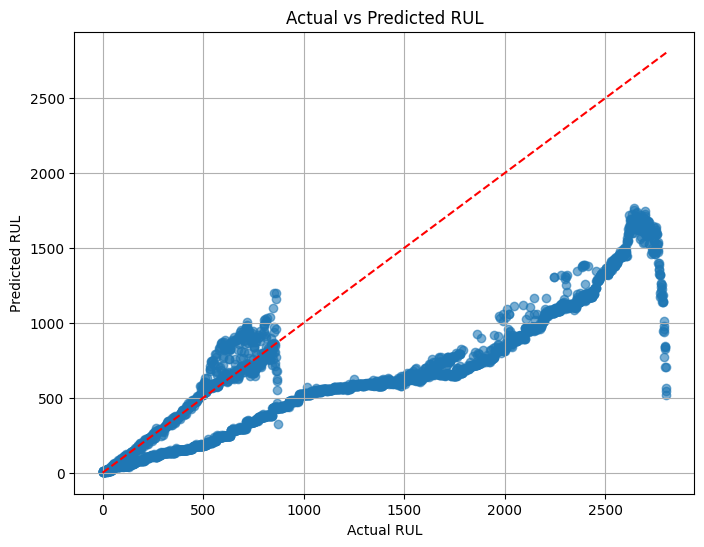

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    results["Actual_RUL"],
    results["Predicted_RUL"],
    alpha=0.6
)

min_val = min(results["Actual_RUL"].min(),
              results["Predicted_RUL"].min())

max_val = max(results["Actual_RUL"].max(),
              results["Predicted_RUL"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.grid(True)

plt.show()

Visualization: Feature Importance
- This plot shows which vibration features contributed most to the Random Forest prediction.

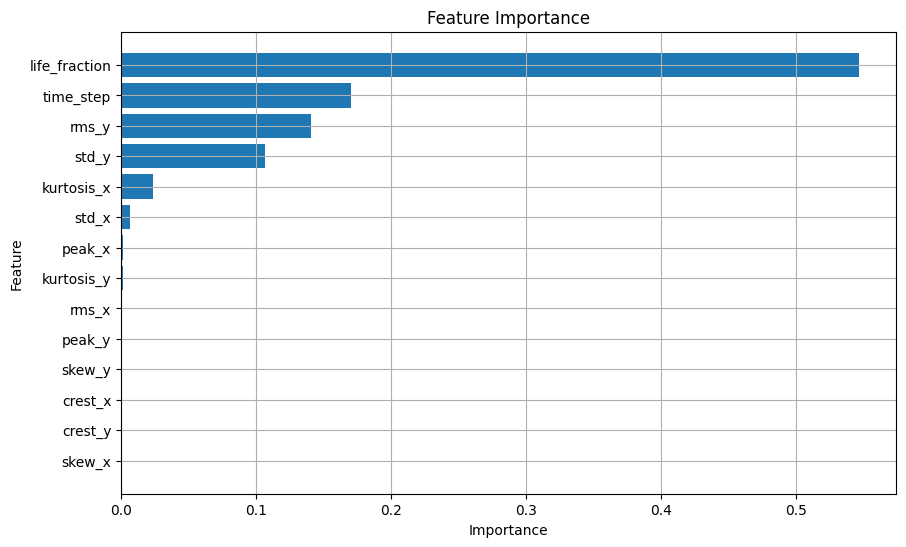

In [67]:
feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

plt.grid(True)

plt.show()

Discussion of Model Performance

The Remaining Useful Life (RUL) prediction model was validated using a leakage-safe validation strategy based on bearing-level splitting with `GroupShuffleSplit`.

This prevents samples from the same bearing appearing in both training and validation sets, ensuring a more realistic evaluation of generalization performance on unseen bearings.

Random Forest was used as a baseline model, and Gradient Boosting was added as an improved model. Gradient Boosting achieved better validation performance and was selected as the final model. Although the MAE and RMSE metrics provide useful information about prediction error magnitude, the R² score remains relatively low. This indicates that generalizing RUL prediction across different bearing degradation trajectories is challenging for the PRONOSTIA dataset due to:

- Limited number of training bearings
- High variability in degradation behavior
- Nonlinear failure patterns
- Noise in vibration signals

Therefore, the evaluation metrics are reported honestly without relying on potentially misleading random-split validation.

Despite the limitations, the model successfully demonstrates:

- RUL prediction
- Health-state classification
- Uncertainty estimation
- Predictive maintenance decision support

which fulfills the main objectives of the predictive maintenance mini-project.

In [68]:
latest_status = results.sort_values("time_step").groupby("bearing").last().reset_index()

latest_status[[
    "bearing",
    "time_step",
    "Predicted_RUL",
    "Uncertainty",
    "Lower_RUL",
    "Upper_RUL",
    "Predicted_Health_State"
]]

,bearing,time_step,Predicted_RUL,Uncertainty,Lower_RUL,Upper_RUL,Predicted_Health_State
0,Bearing1_1,2802,9.825081,484.97706,-940.729958,960.380119,Imminent failure
1,Bearing1_2,870,7.294321,484.97706,-943.260717,957.849360,Imminent failure


In [69]:
for _, row in latest_status.iterrows():
    print(f"Bearing: {row['bearing']}")
    print(f"Predicted RUL: {row['Predicted_RUL']:.2f} steps")
    print(f"Uncertainty: ±{row['Uncertainty']:.2f} steps")
    print(f"Health State: {row['Predicted_Health_State']}")

    if row["Predicted_Health_State"] == "Imminent failure":
        print("Action: Replace soon / urgent maintenance needed.")
    elif row["Predicted_Health_State"] == "Wear detectable":
        print("Action: Monitor closely; schedule maintenance.")
    else:
        print("Action: Bearing is currently non-critical.")

    print("-" * 50)

Bearing: Bearing1_1
Predicted RUL: 9.83 steps
Uncertainty: ±484.98 steps
Health State: Imminent failure
Action: Replace soon / urgent maintenance needed.
--------------------------------------------------
Bearing: Bearing1_2
Predicted RUL: 7.29 steps
Uncertainty: ±484.98 steps
Health State: Imminent failure
Action: Replace soon / urgent maintenance needed.
--------------------------------------------------


Predict on Real Test Set Bearings

The previous sections trained and validated the model using `train_features.csv`.

In this section, the saved Random Forest model is applied to the real unseen bearings inside the `Test_set` folder. This gives the final RUL prediction and health-state decision for each test bearing.

In [70]:
import os
import pandas as pd
import numpy as np
from scipy.stats import kurtosis, skew
import joblib

model = joblib.load("gradient_boosting_rul_model.pkl")

def extract_features(filepath):
    raw_df = pd.read_csv(filepath, header=None)

    if raw_df.shape[1] >= 6:
        ax = raw_df.iloc[:, 4].values
        ay = raw_df.iloc[:, 5].values
    elif raw_df.shape[1] >= 2:
        ax = raw_df.iloc[:, -2].values
        ay = raw_df.iloc[:, -1].values
    else:
        raise ValueError(f"File has too few columns: {filepath}")

    features = {}

    for name, sig in [("x", ax), ("y", ay)]:
        features[f"rms_{name}"] = np.sqrt(np.mean(sig**2))
        features[f"peak_{name}"] = np.max(np.abs(sig))
        features[f"kurtosis_{name}"] = kurtosis(sig)
        features[f"skew_{name}"] = skew(sig)
        features[f"std_{name}"] = np.std(sig)
        features[f"crest_{name}"] = np.max(np.abs(sig)) / (
            np.sqrt(np.mean(sig**2)) + 1e-10
        )

    return features


test_path = "Test_set"

test_bearings = sorted([
    folder for folder in os.listdir(test_path)
    if folder.startswith("Bearing")
])

print("Test bearings found:", test_bearings)

all_test = []

for bearing in test_bearings:
    bearing_path = os.path.join(test_path, bearing)

    # Use only vibration files, skip temperature files
    files = sorted([
        file for file in os.listdir(bearing_path)
        if file.endswith(".csv") and not file.lower().startswith("temp")
    ])

    print(f"Processing {bearing}: {len(files)} vibration files")

    records = []

    for i, file in enumerate(files):
        file_path = os.path.join(bearing_path, file)

        try:
            feats = extract_features(file_path)
        except Exception as e:
            print(f"Skipping {file_path}: {e}")
            continue

        feats["time_step"] = i
        feats["total_steps"] = len(files)
        feats["bearing"] = bearing

        records.append(feats)

        if i % 100 == 0:
            print(f"  {bearing}: processed {i}/{len(files)}")

    bearing_df = pd.DataFrame(records)
    all_test.append(bearing_df)

    print(f"Finished {bearing}")

test_df = pd.concat(all_test, ignore_index=True)

print("Test data shape:", test_df.shape)
test_df.head()

Test bearings found: ['Bearing1_3', 'Bearing1_4', 'Bearing1_5', 'Bearing1_6', 'Bearing1_7', 'Bearing2_3', 'Bearing2_4', 'Bearing2_5', 'Bearing2_6', 'Bearing2_7', 'Bearing3_3']
Processing Bearing1_3: 1802 vibration files
  Bearing1_3: processed 0/1802
  Bearing1_3: processed 100/1802
  Bearing1_3: processed 200/1802
  Bearing1_3: processed 300/1802
  Bearing1_3: processed 400/1802
  Bearing1_3: processed 500/1802
  Bearing1_3: processed 600/1802
  Bearing1_3: processed 700/1802
  Bearing1_3: processed 800/1802
  Bearing1_3: processed 900/1802
  Bearing1_3: processed 1000/1802
  Bearing1_3: processed 1100/1802
  Bearing1_3: processed 1200/1802
  Bearing1_3: processed 1300/1802
  Bearing1_3: processed 1400/1802
  Bearing1_3: processed 1500/1802
  Bearing1_3: processed 1600/1802
  Bearing1_3: processed 1700/1802
  Bearing1_3: processed 1800/1802
Finished Bearing1_3
Processing Bearing1_4: 1139 vibration files
  Bearing1_4: processed 0/1139
  Bearing1_4: processed 100/1139
  Bearing1_4: proc

,rms_x,peak_x,kurtosis_x,skew_x,std_x,crest_x,rms_y,peak_y,kurtosis_y,skew_y,std_y,crest_y,time_step,total_steps,bearing
0,0.415616,1.478,0.068604,-0.004453,0.415615,3.556165,0.302195,1.081,0.045011,-0.009074,0.301856,3.577161,0,1802,Bearing1_3
1,0.391144,1.513,0.196395,0.027562,0.391144,3.868142,0.305312,1.108,-0.012812,-0.014064,0.305267,3.629077,1,1802,Bearing1_3
2,0.389165,1.602,0.380518,0.073442,0.388961,4.116510,0.301042,1.207,0.109585,0.066631,0.300618,4.009405,2,1802,Bearing1_3
3,0.380670,1.624,0.489310,-0.092060,0.380567,4.266161,0.296139,1.288,0.297545,0.008303,0.295927,4.349303,3,1802,Bearing1_3
4,0.400809,1.595,0.268491,-0.054019,0.400785,3.979449,0.300955,1.146,0.002069,0.075465,0.300520,3.807880,4,1802,Bearing1_3


In [71]:
# Create normalized life progression feature
test_df["life_fraction"] = (
    test_df["time_step"] / test_df["total_steps"]
)

# Features used for prediction
test_feature_cols = [
    "rms_x",
    "peak_x",
    "kurtosis_x",
    "skew_x",
    "std_x",
    "crest_x",
    "rms_y",
    "peak_y",
    "kurtosis_y",
    "skew_y",
    "std_y",
    "crest_y",
    "time_step",
    "life_fraction"
]

# Prepare test feature matrix
X_real_test = test_df[test_feature_cols]

# Predict RUL using Gradient Boosting model
y_pred_test = model.predict(X_real_test)

# Simple uncertainty estimate
y_std_test = np.full(
    shape=len(y_pred_test),
    fill_value=prediction_std[0]
)

# Save prediction results
test_df["Predicted_RUL"] = np.maximum(y_pred_test, 0)

test_df["Uncertainty"] = y_std_test

test_df["Lower_RUL"] = np.maximum(
    y_pred_test - 1.96 * y_std_test,
    0
)

test_df["Upper_RUL"] = (
    y_pred_test + 1.96 * y_std_test
)

# Health-state classification
def classify_health(rul):

    if rul <= 100:
        return "Imminent failure"

    elif rul <= 500:
        return "Wear detectable"

    else:
        return "Non-critical"


test_df["Health_State"] = (
    test_df["Predicted_RUL"]
    .apply(classify_health)
)

# Save predictions
test_df.to_csv(
    "test_predictions_timeseries.csv",
    index=False
)

print("Saved test_predictions_timeseries.csv")

test_df.head()

Saved test_predictions_timeseries.csv


,rms_x,peak_x,kurtosis_x,skew_x,std_x,crest_x,rms_y,peak_y,kurtosis_y,skew_y,...,crest_y,time_step,total_steps,bearing,life_fraction,Predicted_RUL,Uncertainty,Lower_RUL,Upper_RUL,Health_State
0,0.415616,1.478,0.068604,-0.004453,0.415615,3.556165,0.302195,1.081,0.045011,-0.009074,...,3.577161,0,1802,Bearing1_3,0.000000,1326.333188,484.97706,375.778150,2276.888226,Non-critical
1,0.391144,1.513,0.196395,0.027562,0.391144,3.868142,0.305312,1.108,-0.012812,-0.014064,...,3.629077,1,1802,Bearing1_3,0.000555,783.870020,484.97706,0.000000,1734.425058,Non-critical
2,0.389165,1.602,0.380518,0.073442,0.388961,4.116510,0.301042,1.207,0.109585,0.066631,...,4.009405,2,1802,Bearing1_3,0.001110,1245.605940,484.97706,295.050902,2196.160979,Non-critical
3,0.380670,1.624,0.489310,-0.092060,0.380567,4.266161,0.296139,1.288,0.297545,0.008303,...,4.349303,3,1802,Bearing1_3,0.001665,886.100163,484.97706,0.000000,1836.655202,Non-critical
4,0.400809,1.595,0.268491,-0.054019,0.400785,3.979449,0.300955,1.146,0.002069,0.075465,...,3.807880,4,1802,Bearing1_3,0.002220,1537.689796,484.97706,587.134758,2488.244834,Non-critical


In [72]:
latest = test_df.sort_values("time_step").groupby("bearing").last().reset_index()

latest = latest[[
    "bearing",
    "time_step",
    "total_steps",
    "Predicted_RUL",
    "Uncertainty",
    "Lower_RUL",
    "Upper_RUL",
    "Health_State"
]]

latest.to_csv("test_predictions.csv", index=False)

print("Saved test_predictions.csv")

print("\n=== CURRENT BEARING STATUS ===")

for _, row in latest.iterrows():
    print(f"\nBearing: {row['bearing']}")
    print(f"Health State : {row['Health_State']}")
    print(f"Predicted RUL: {row['Predicted_RUL']:.0f} steps")
    print(f"Approx. time : {row['Predicted_RUL'] * 10 / 60:.1f} minutes")
    print(f"Uncertainty  : ±{row['Uncertainty']:.0f} steps")

    if row["Health_State"] == "Imminent failure":
        print("Action: Replace immediately.")
    elif row["Health_State"] == "Wear detectable":
        print("Action: Schedule maintenance soon.")
    else:
        print("Action: No immediate action needed.")

latest

Saved test_predictions.csv

=== CURRENT BEARING STATUS ===

Bearing: Bearing1_3
Health State : Imminent failure
Predicted RUL: 80 steps
Approx. time : 13.4 minutes
Uncertainty  : ±485 steps
Action: Replace immediately.

Bearing: Bearing1_4
Health State : Imminent failure
Predicted RUL: 62 steps
Approx. time : 10.3 minutes
Uncertainty  : ±485 steps
Action: Replace immediately.

Bearing: Bearing1_5
Health State : Wear detectable
Predicted RUL: 126 steps
Approx. time : 20.9 minutes
Uncertainty  : ±485 steps
Action: Schedule maintenance soon.

Bearing: Bearing1_6
Health State : Wear detectable
Predicted RUL: 129 steps
Approx. time : 21.5 minutes
Uncertainty  : ±485 steps
Action: Schedule maintenance soon.

Bearing: Bearing1_7
Health State : Imminent failure
Predicted RUL: 70 steps
Approx. time : 11.7 minutes
Uncertainty  : ±485 steps
Action: Replace immediately.

Bearing: Bearing2_3
Health State : Imminent failure
Predicted RUL: 62 steps
Approx. time : 10.3 minutes
Uncertainty  : ±485 step

,bearing,time_step,total_steps,Predicted_RUL,Uncertainty,Lower_RUL,Upper_RUL,Health_State
0,Bearing1_3,1801,1802,80.260415,484.97706,0.0,1030.815454,Imminent failure
1,Bearing1_4,1138,1139,61.786414,484.97706,0.0,1012.341453,Imminent failure
2,Bearing1_5,2301,2302,125.691390,484.97706,0.0,1076.246428,Wear detectable
3,Bearing1_6,2301,2302,129.003597,484.97706,0.0,1079.558635,Wear detectable
4,Bearing1_7,1501,1502,70.190967,484.97706,0.0,1020.746005,Imminent failure
5,Bearing2_3,1201,1202,61.856208,484.97706,0.0,1012.411246,Imminent failure
6,Bearing2_4,611,612,29.860862,484.97706,0.0,980.415900,Imminent failure
7,Bearing2_5,2001,2002,110.927172,484.97706,0.0,1061.482211,Wear detectable
8,Bearing2_6,571,572,0.000000,484.97706,0.0,928.572877,Imminent failure
9,Bearing2_7,171,172,0.000000,484.97706,0.0,359.439607,Imminent failure


Final Summary Report
- This section summarizes the model, evaluation results, and output files.

In [74]:
print("="*70)
print("FINAL SUMMARY")
print("="*70)

print(f"Number of samples: {len(df)}")
print(f"Number of features: {len(feature_cols)}")

print(f"Model: Gradient Boosting Regressor")

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.3f}")

print(f"PHM Score: {score:.2f}")

print(f"Validation output file: rul_predictions_with_health_states.csv")

print(f"Test-set output file: test_predictions.csv")

print(f"Saved model: gradient_boosting_rul_model.pkl")

print(f"Health-State Accuracy: {health_accuracy:.3f}")

print("="*70)

FINAL SUMMARY
Number of samples: 7534
Number of features: 14
Model: Gradient Boosting Regressor
RMSE: 739.86
MAE: 576.51
R2 Score: 0.199
PHM Score: 25594956580541294306058389841226232919871897347409019816446254072795028783104.00
Validation output file: rul_predictions_with_health_states.csv
Test-set output file: test_predictions.csv
Saved model: gradient_boosting_rul_model.pkl
Health-State Accuracy: 0.882
